In [28]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_gridFit/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


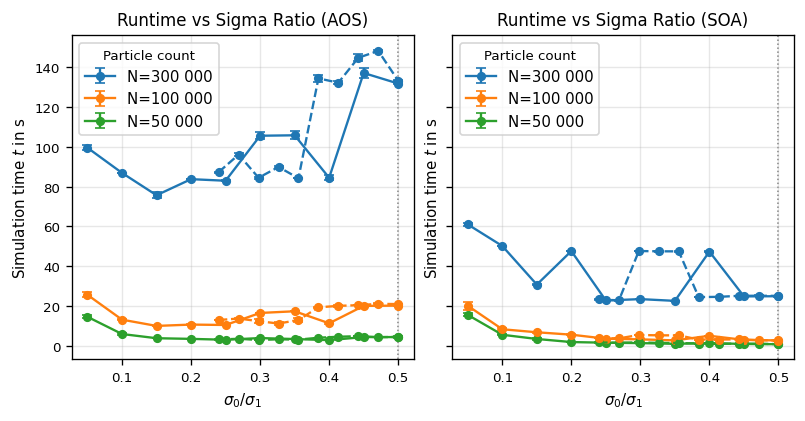

Plot mapping: solid line (-) = gridFitOff, dashed line (--) = gridFitOff2.
Saved: ../thesis_plots/gridFit.pdf
Vertical markers shown at sigma_ratio values present in both gridFitOff and gridFitOff2.


In [29]:
def fitted_grid_transition_sigmas_from_last_cell(max_ratio: int = 13, dense_points: int = 20000) -> list[float]:
    """Read all fitted-grid transition positions in the plotted sigma range (fitted only)."""
    analysis_df = globals().get("df")
    if analysis_df is None:
        return []

    required = {"sigma_ratio", "num_levels", "higher_over_lower_true_x"}
    if not required.issubset(set(analysis_df.columns)):
        return []

    runtime = globals().get("runtime_df")
    if runtime is not None and not runtime.empty and "sigma_ratio" in runtime.columns:
        sigma_min = float(runtime["sigma_ratio"].min())
        sigma_max = float(runtime["sigma_ratio"].max())
    else:
        sigma_min = float(analysis_df["sigma_ratio"].min())
        sigma_max = float(analysis_df["sigma_ratio"].max())

    if "hgmatching_cell_sizes_both_modes" in globals():
        dense_sigmas = np.linspace(sigma_min, sigma_max, dense_points)
        dense_res = hgmatching_cell_sizes_both_modes(dense_sigmas)
        fitted = pd.DataFrame(
            {
                "sigma_ratio": [r["sigma_ratio"] for r in dense_res],
                "num_levels": [r["num_levels"] for r in dense_res],
                "ratio_true": [r["higher_cell_length"][0] / r["lower_cell_length_true"][0] for r in dense_res],
            }
        )
    else:
        fitted = analysis_df.rename(columns={"higher_over_lower_true_x": "ratio_true"})[["sigma_ratio", "num_levels", "ratio_true"]].copy()

    fitted = fitted.loc[fitted["num_levels"] >= 2].copy()
    if fitted.empty:
        return []

    fitted = fitted.sort_values("sigma_ratio").drop_duplicates(subset=["sigma_ratio"], keep="last")
    sigmas = fitted["sigma_ratio"].astype(float).to_numpy()
    ratios = fitted["ratio_true"].astype(float).to_numpy()

    transitions = []
    for i in range(len(sigmas) - 1):
        if abs(ratios[i + 1] - ratios[i]) > 1e-12 and ratios[i] <= max_ratio:
            transitions.append(float(0.5 * (sigmas[i] + sigmas[i + 1])))

    return transitions


# Collect data and generate one export-ready figure
runtime_df = collect_runtime_data(".")
runtime_df = runtime_df[runtime_df["total_particles"] != 1000].copy()

# If your LaTeX setup has full TeX support for Matplotlib, set this to True.
apply_scrbook_11pt_style(use_latex=False)

if runtime_df.empty:
    print("No logOutput_*.out files found below current directory.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.4), sharey=True, constrained_layout=True)
    plot_runtime_vs_sigma(runtime_df, "AoS", ax=axes[0], error_mode="t86", legend_loc="upper left")
    plot_runtime_vs_sigma(runtime_df, "SoA", ax=axes[1], error_mode="t86")

    output_dir = Path("..") / "thesis_plots"
    output_dir.mkdir(exist_ok=True)

    pdf_path = output_dir / "gridFit.pdf"

    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    print("Plot mapping: solid line (-) = gridFitOff, dashed line (--) = gridFitOff2.")
    print(f"Saved: {pdf_path}")
    print("Vertical markers shown at sigma_ratio values present in both gridFitOff and gridFitOff2.")

In [ ]:
# Compare gridFitOff vs gridFitOff2 at common sigma_ratio values
# and report which mode is faster and by how much.

if "runtime_df" not in globals() or runtime_df is None or runtime_df.empty:
    runtime_df = collect_runtime_data(".")

analysis = runtime_df.copy()
analysis = analysis[analysis["total_particles"] != 1000].copy()
analysis = analysis[~analysis["sigma_ratio"].round(2).eq(0.55)].copy()

# Mean runtime per mode for each (layout, particle count, sigma)
summary = (
    analysis.groupby(["data_layout", "total_particles", "sigma_ratio", "grid_fit"], as_index=False)
    .agg(seconds_mean=("seconds", "mean"), n=("seconds", "count"))
)

pivot = (
    summary.pivot_table(
        index=["data_layout", "total_particles", "sigma_ratio"],
        columns="grid_fit",
        values="seconds_mean",
        aggfunc="first",
    )
    .reset_index()
)

required_modes = {"gridFitOff", "gridFitOff2"}
if not required_modes.issubset(set(pivot.columns)):
    print("Could not compare: one or both modes are missing in the data.")
else:
    common = pivot.dropna(subset=["gridFitOff", "gridFitOff2"]).copy()

    if common.empty:
        print("No common sigma_ratio points found between gridFitOff and gridFitOff2.")
    else:
        common["faster_mode"] = common.apply(
            lambda r: "gridFitOff" if r["gridFitOff"] < r["gridFitOff2"] else "gridFitOff2",
            axis=1,
        )
        common["faster_time_s"] = common[["gridFitOff", "gridFitOff2"]].min(axis=1)
        common["slower_time_s"] = common[["gridFitOff", "gridFitOff2"]].max(axis=1)
        common["diff_s"] = common["slower_time_s"] - common["faster_time_s"]
        common["diff_pct_vs_slower"] = 100.0 * common["diff_s"] / common["slower_time_s"]

        result = common[
            [
                "data_layout",
                "total_particles",
                "sigma_ratio",
                "gridFitOff",
                "gridFitOff2",
                "faster_mode",
                "diff_s",
                "diff_pct_vs_slower",
            ]
        ].sort_values(["data_layout", "total_particles", "sigma_ratio"])

        print("Per shared sigma_ratio point: faster mode and speedup magnitude")
        display(result)

        overall = (
            result.groupby("faster_mode", as_index=False)
            .agg(
                points_won=("faster_mode", "count"),
                mean_diff_s=("diff_s", "mean"),
                mean_diff_pct=("diff_pct_vs_slower", "mean"),
            )
            .sort_values("points_won", ascending=False)S
        )

        print("\nOverall summary across shared points")
        display(overall)


Per shared sigma_ratio point: faster mode and speedup magnitude


grid_fit,data_layout,total_particles,sigma_ratio,gridFitOff,gridFitOff2,faster_mode,diff_s,diff_pct_vs_slower
18,AoS,50000,0.5,4.466667,4.571667,gridFitOff,0.105000,2.296755
37,AoS,100000,0.5,20.251333,21.031000,gridFitOff,0.779667,3.707226
56,AoS,300000,0.5,131.708667,133.150333,gridFitOff,1.441667,1.082736
75,SoA,50000,0.5,0.876667,0.905000,gridFitOff,0.028333,3.130755
94,SoA,100000,0.5,2.785333,2.739333,gridFitOff2,0.046000,1.651508
113,SoA,300000,0.5,24.976000,25.144000,gridFitOff,0.168000,0.668151



Overall summary across shared points


,faster_mode,points_won,mean_diff_s,mean_diff_pct
0,gridFitOff,5,0.504533,2.177125
1,gridFitOff2,1,0.046000,1.651508


In [31]:
import math
import numpy as np
import pandas as pd


def _cellblock3d_cell_length(box_min, box_max, interaction_length, cell_size_factor=1.0):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellSizeFactor."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min

    # CellBlock3D behavior for csf >= 1.0 / < 1.0 only affects halo width, not owned cell length.
    cells_per_dim = np.maximum(np.floor(box_lengths / (interaction_length * cell_size_factor)).astype(int), 1)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def _cellblock3d_cell_length_from_cells_per_dim(box_min, box_max, cells_per_dim):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellsPerDimension."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min
    cells_per_dim = np.asarray(cells_per_dim, dtype=int)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def hgmatching_cell_sizes_both_modes(
    sigma_ratios,
    box_min=(0.0, 0.0, 0.0),
    box_max=(20.0, 20.0, 20.0),
    skin=0.1,
    higher_cutoff=3.0,
    cell_size_factor=1.0,
    sigma_max=1.0,
    cutoff_scale=3.0,
    use_generator_rounding=True,
):
    """
    Mimic HierarchicalGridMatching + LinkedCells + CellBlock3D for both fittedGrids=false and fittedGrids=true.

    Returns per sigma ratio:
    - higher cell length
    - lower cell length for fittedGrids=false (ratio-based csf)
    - lower cell length for fittedGrids=true (cellsPerDimension path)
    - lowerCellsPerHigher check values
    """
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)

    max_length = float(np.min(box_max - box_min) - skin)
    out = []

    for sigma_ratio in sigma_ratios:
        sigma0 = sigma_max * float(sigma_ratio)
        cutoff0 = cutoff_scale * sigma0
        if use_generator_rounding:
            # input_generator writes cutoff0 with 6 decimals.
            cutoff0 = float(f"{cutoff0:.6f}")

        # Mimic constructor preprocessing: clamp > maxLength, sort, unique.
        cutoffs = sorted({min(cutoff0, max_length), min(higher_cutoff, max_length)})

        # Highest level (always constructed first with cellSizeFactor).
        highest_interaction = cutoffs[-1] + skin
        higher_cell_length, higher_cells_per_dim = _cellblock3d_cell_length(
            box_min, box_max, highest_interaction, cell_size_factor
        )

        # If lower cutoff collapsed away through uniqueness, only one level exists.
        if len(cutoffs) < 2:
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": np.array([np.nan, np.nan, np.nan]),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        lower_interaction = cutoffs[0] + skin

        # Pre-check in HierarchicalGridMatching before branch on fittedGrids.
        lower_cells_per_higher = np.floor(higher_cell_length / (lower_interaction * cell_size_factor)).astype(int)
        if np.any(lower_cells_per_higher < 2):
            # Level removed, hierarchy degenerates to highest level only.
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": lower_cells_per_higher.copy(),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        # fittedGrids == false branch: ratio-based cellSizeFactor for lower level.
        ratio = lower_interaction / highest_interaction
        lower_csf = cell_size_factor * ratio
        lower_cell_length_false, _ = _cellblock3d_cell_length(box_min, box_max, highest_interaction, lower_csf)

        # fittedGrids == true branch: explicitly matched cellsPerDimension.
        lower_cells_per_dim_true = lower_cells_per_higher * higher_cells_per_dim
        lower_cell_length_true, _ = _cellblock3d_cell_length_from_cells_per_dim(
            box_min, box_max, lower_cells_per_dim_true
        )

        out.append(
            {
                "sigma_ratio": float(sigma_ratio),
                "num_levels": 2,
                "lower_cells_per_higher": lower_cells_per_higher.copy(),
                "higher_cell_length": higher_cell_length.copy(),
                "lower_cell_length_false": lower_cell_length_false.copy(),
                "lower_cell_length_true": lower_cell_length_true.copy(),
            }
        )

    return out


# Example on your current gridFit sigma ratios.
#sigmas = np.linspace(0.24, 0.50, 10)
sigmas = [0.24, 0.268889, 0.297778, 0.326667, 0.355556, 0.384444, 0.413333, 0.442222, 0.471111, 0.5]
res = hgmatching_cell_sizes_both_modes(sigmas)

df = pd.DataFrame(
    {
        "sigma_ratio": [r["sigma_ratio"] for r in res],
        "num_levels": [r["num_levels"] for r in res],
        "lower_cells_per_higher_x": [
            (int(r["lower_cells_per_higher"][0]) if not np.isnan(r["lower_cells_per_higher"][0]) else np.nan)
            for r in res
        ],
        "higher_cell_length_x": [r["higher_cell_length"][0] for r in res],
        "higher_over_lower_false_x": [r["higher_cell_length"][0] / r["lower_cell_length_false"][0] for r in res],
        "higher_over_lower_true_x": [r["higher_cell_length"][0] / r["lower_cell_length_true"][0] for r in res],
    }
)

df

,sigma_ratio,num_levels,lower_cells_per_higher_x,higher_cell_length_x,higher_over_lower_false_x,higher_over_lower_true_x
0,0.240000,2,4,3.333333,4.000000,4.0
1,0.268889,2,3,3.333333,3.666667,3.0
2,0.297778,2,3,3.333333,3.333333,3.0
3,0.326667,2,3,3.333333,3.000000,3.0
4,0.355556,2,2,3.333333,2.833333,2.0
5,0.384444,2,2,3.333333,2.500000,2.0
6,0.413333,2,2,3.333333,2.333333,2.0
7,0.442222,2,2,3.333333,2.333333,2.0
8,0.471111,2,2,3.333333,2.166667,2.0
9,0.500000,2,2,3.333333,2.000000,2.0
